## 12.3 K最近邻算法实战——手写字体识别 

In [15]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
digits=datasets.load_digits()

C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\datasets\base.py:549: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  target = data[:, -1].astype(np.int, copy=False)


In [3]:
X=digits['data']
y=digits['target']

In [4]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2)

In [5]:
KNN_classifier=KNeighborsClassifier(n_neighbors=3)

In [6]:
KNN_classifier.fit(X_train,y_train)

C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\neighbors\base.py:908: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  self._y = np.empty(y.shape, dtype=np.int)


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=3, p=2,
                     weights='uniform')

In [7]:
KNN_classifier.score(X_test,y_test)

0.9916666666666667

<h2>糖尿病检测 

In [32]:
#Load the dataset
df = pd.read_csv('diabetes.csv')

#Print the first 5 rows of the dataframe.
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [33]:
#显示数据集的行数和列数
df.shape

(768, 9)

In [34]:
X = df.drop('Outcome',axis=1).values
y = df['Outcome']

In [35]:
#拆分成训练集和测试集
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

In [36]:
#建模
from sklearn.neighbors import KNeighborsClassifier

#邻居个数从1-8个，依此建立KNN分类模型
neighbors = np.arange(1,9)
train_accuracy =np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i,k in enumerate(neighbors):
    #构建模型
    knn = KNeighborsClassifier(n_neighbors=k)
    
    #F拟合模型
    knn.fit(X_train, y_train)
    
    #返回训练集的准确率
    train_accuracy[i] = knn.score(X_train, y_train)
    
    #返回测试集的准确率
    test_accuracy[i] = knn.score(X_test, y_test) 

C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\neighbors\base.py:908: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  self._y = np.empty(y.shape, dtype=np.int)
C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\neighbors\base.py:908: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you

In [37]:
test_accuracy

array([0.6969697 , 0.72294372, 0.70562771, 0.69264069, 0.71861472,
       0.74025974, 0.73593074, 0.73160173])

In [38]:
train_accuracy

array([1.        , 0.82309125, 0.83054004, 0.79143389, 0.80074488,
       0.77653631, 0.7839851 , 0.76908752])

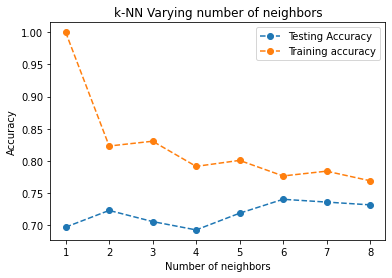

In [39]:
#画图
plt.title('k-NN Varying number of neighbors')
plt.plot(neighbors, test_accuracy, label='Testing Accuracy',linestyle='--',marker='o')
plt.plot(neighbors, train_accuracy, label='Training accuracy',linestyle='--',marker='o')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')
plt.show()

In [40]:
#测试集在邻居数为7时效果最好，因此决定使用该参数建模
knn = KNeighborsClassifier(n_neighbors=7)

In [41]:
#拟合模型
knn.fit(X_train,y_train)

C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\neighbors\base.py:908: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  self._y = np.empty(y.shape, dtype=np.int)


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=7, p=2,
                     weights='uniform')

In [42]:
y_pred = knn.predict(X_test)###预测

In [43]:
#输出混淆矩阵
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[120,  23],
       [ 38,  50]], dtype=int64)

In [44]:
knn.score(X_test,y_test)

0.7359307359307359

<h2>参数搜索和交叉验证

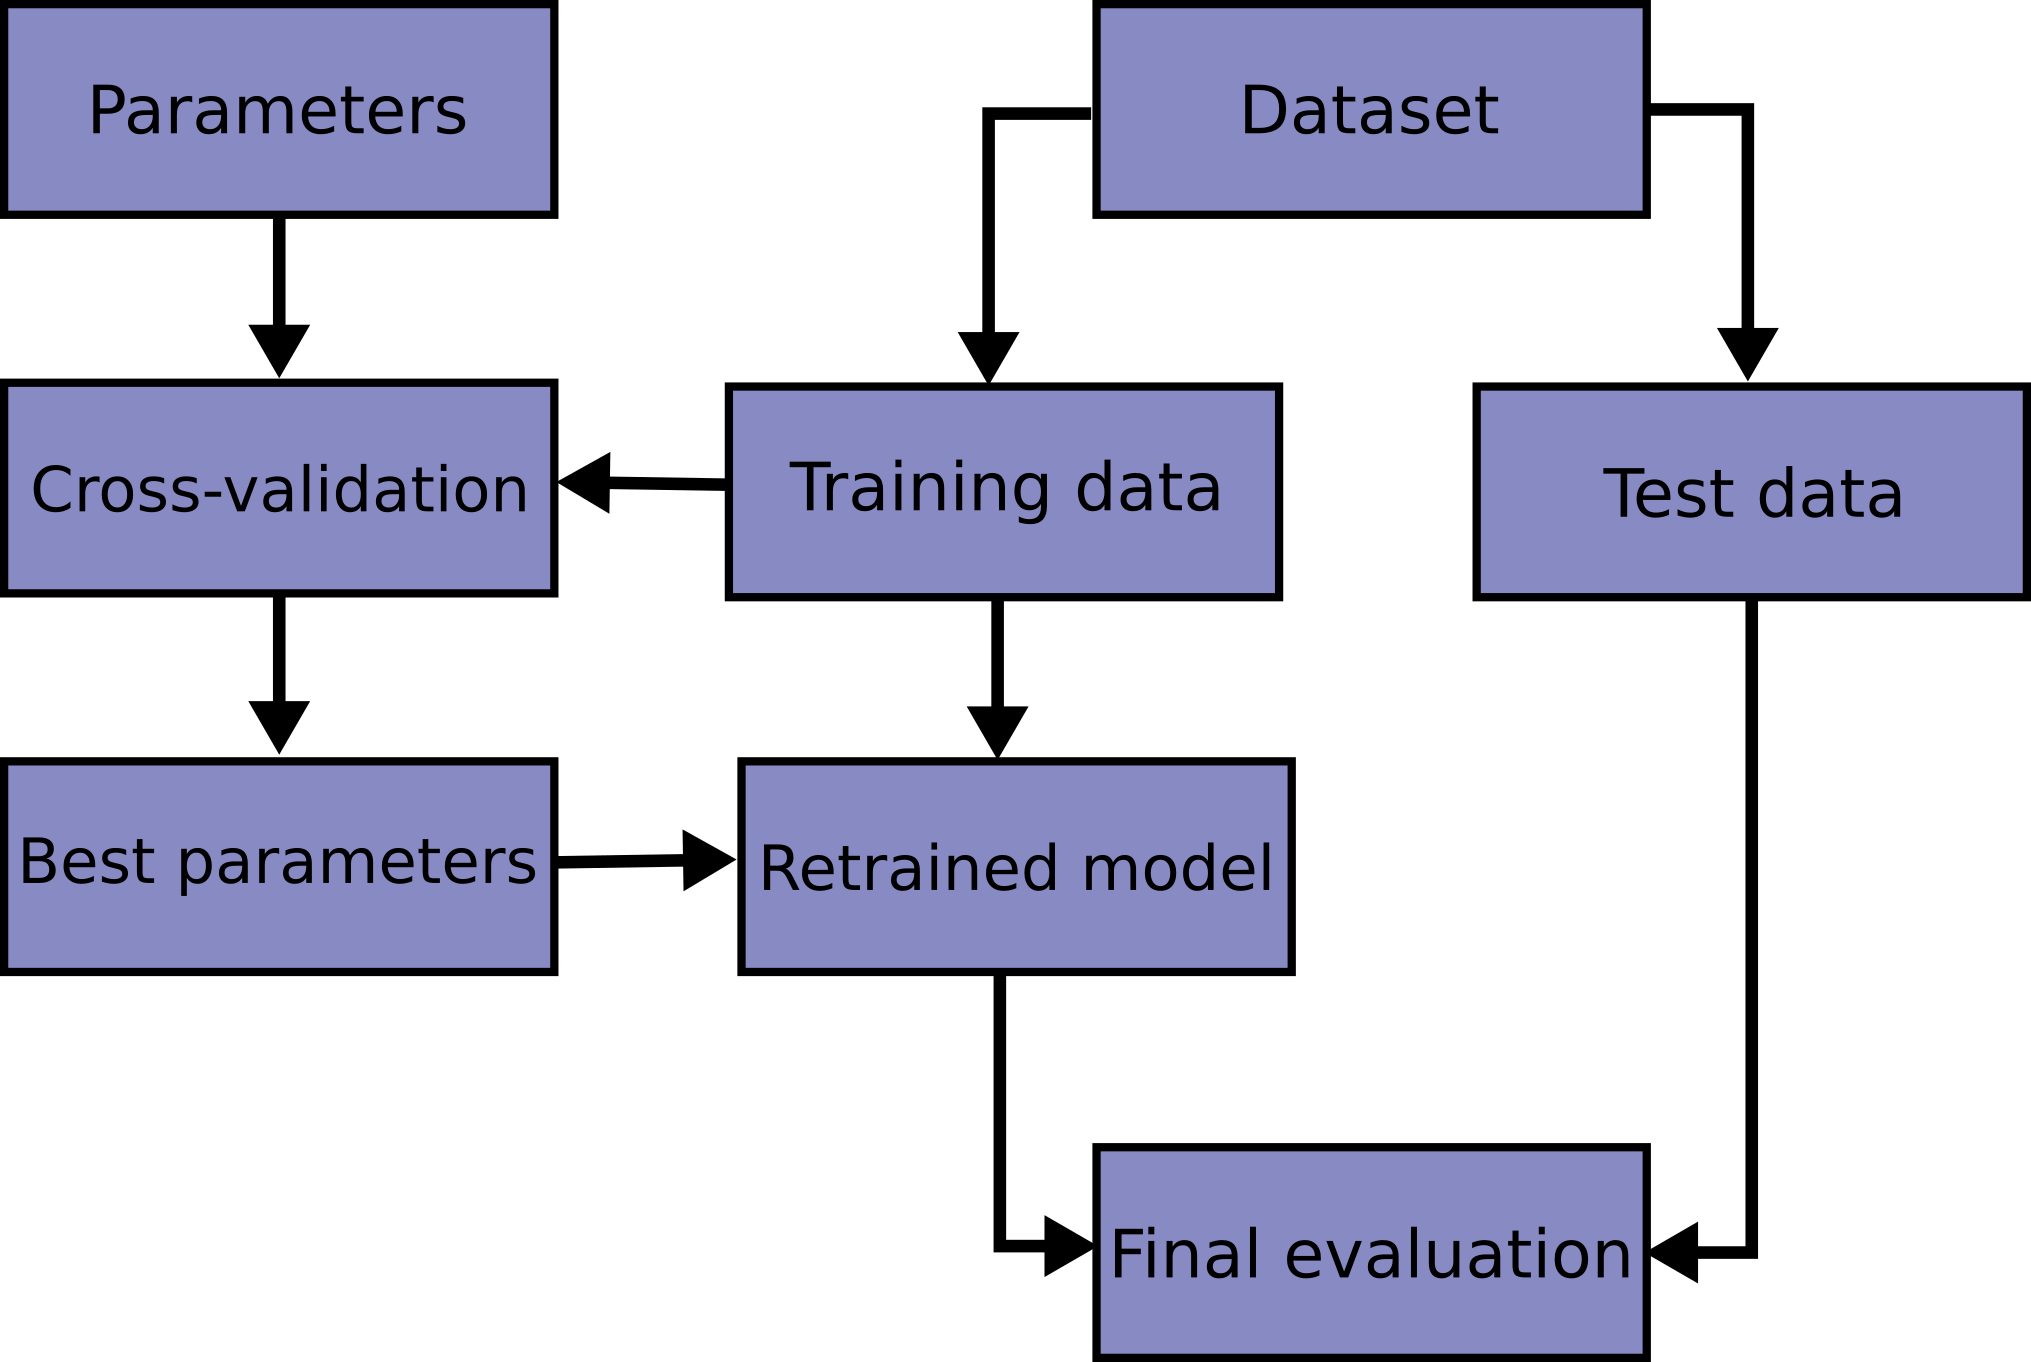

In [46]:
from IPython.display import Image
Image("grid_search_workflow.png")

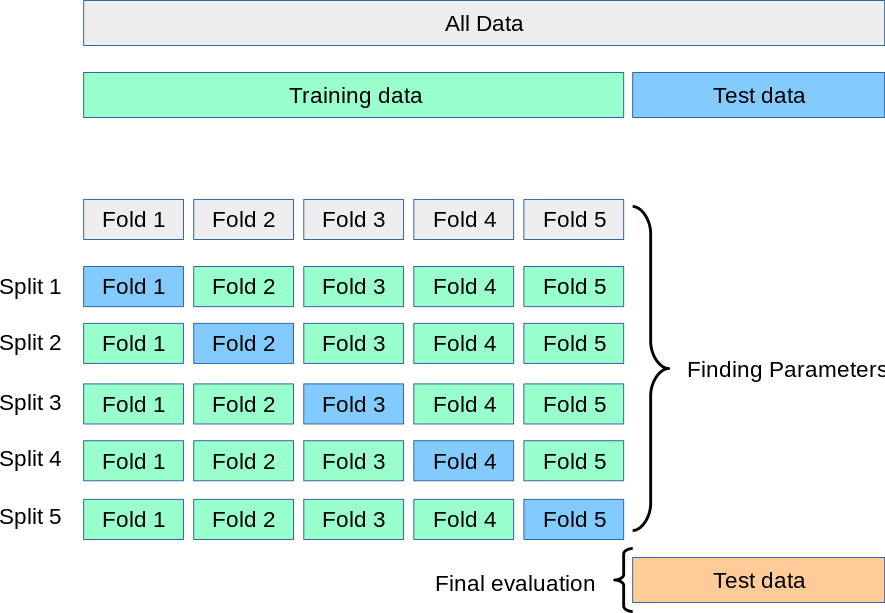

In [50]:
from IPython.display import Image
Image("grid_search_cross_validation.png")


In [52]:
from sklearn.model_selection import GridSearchCV
knn = KNeighborsClassifier()
#构造一些参数的值进行搜索，为字典格式
param = {"n_neighbors":[1,2,3,4,5,6,7]}#选择k值分别为1，2，3，4，5，6，7，在其中寻优
#超参数搜索
gc = GridSearchCV(knn,param_grid=param,cv=3) 
gc.fit(X_train,y_train)

#print("每个超参数每次交叉验证的结果：",gc.cv_results_)
pd.DataFrame(gc.cv_results_)

C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\model_selection\_split.py:670: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  test_folds = np.zeros(n_samples, dtype=np.int)
C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\model_selection\_split.py:442: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify 

C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\neighbors\base.py:908: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  self._y = np.empty(y.shape, dtype=np.int)
C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\neighbors\base.py:908: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001330,0.001881,0.012000,0.000002,1,{'n_neighbors': 1},0.631285,0.608939,0.653631,0.631285,0.018246,7
1,0.001348,0.001906,0.009323,0.001927,2,{'n_neighbors': 2},0.681564,0.715084,0.720670,0.705773,0.017269,5
2,0.000000,0.000000,0.010660,0.001921,3,{'n_neighbors': 3},0.687151,0.731844,0.681564,0.700186,0.022501,6
3,0.000000,0.000000,0.007997,0.000027,4,{'n_neighbors': 4},0.703911,0.726257,0.709497,0.713222,0.009495,3
4,0.002658,0.001880,0.006677,0.001873,5,{'n_neighbors': 5},0.743017,0.743017,0.698324,0.728119,0.021068,1
5,0.001344,0.001900,0.007989,0.000012,6,{'n_neighbors': 6},0.726257,0.715084,0.692737,0.711359,0.013935,4
6,0.000000,0.000000,0.008003,0.000025,7,{'n_neighbors': 7},0.731844,0.754190,0.687151,0.724395,0.027871,2


<li>n_neighbors=1时，在第0折的validat set上的分数是0.631285，在第1折的validat set上的分数是0.608939，在第2折的validat set上的分数是0.653631，平均值是0.631285。
<li>最好的分数是当n_neighbors=5时。

In [53]:
print("选择最好的模型是：",gc.best_estimator_)

选择最好的模型是： KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=5, p=2,
                     weights='uniform')


In [54]:
print("在交叉验证中最好的结果：",gc.best_score_)

在交叉验证中最好的结果： 0.7281191806331471


In [56]:
knn_best=gc.best_estimator_ ##保存最好的模型
knn_best.fit(X_train,y_train) ##在trainset（包含验证集）上做训练
knn_best.score(X_test,y_test) ##在testset上预测

C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\neighbors\base.py:908: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  self._y = np.empty(y.shape, dtype=np.int)


0.7186147186147186

In [57]:
print("在测试集上的准确率：",gc.score(X_test,y_test)) ##由此可见，gc.socre使用最好的模型在trainset上训练，在testset上测试

在测试集上的准确率： 0.7186147186147186
